# 3. Desarrollo
## 3.1 Estrategia ávida del algoritmo
El criterio ávido utilizado es seleccionar en cada paso la materia que finaliza más temprano.

Para ello, primero se ordenan las materias de forma ascendente según su hora de finalización. Posteriormente, se recorre la lista seleccionando la siguiente materia cuya hora de inicio sea mayor o igual a la hora de finalización de la última materia agregada al horario.

Este enfoque permite maximizar el número de materias que pueden incluirse en el horario sin generar traslapes.

En situaciones donde existe un conflicto entre materias (empalme), el algoritmo permite al usuario decidir cuál conservar, lo cual introduce una ligera variación sobre el enfoque ávido clásico.

Por lo tanto, el algoritmo sigue un criterio ávido basado en minimizar el tiempo de finalización para permitir la mayor cantidad de selecciones posibles sin conflicto.
## 3.2 Algoritmo Horario Académico


1. Crear una lista vacía llamada materias.

2. Solicitar los datos de cada materia:
   nombre, prioridad, hora de inicio y hora de fin.

3. Guardar cada materia en un diccionario.

4. Agregar cada diccionario a la lista materias.

5. Ordenar la lista materias de forma ascendente de acuerdo con la hora de finalización.

6. Crear una lista vacía llamada horario.

7. Recorrer la lista de materias ordenadas.

8. Si el horario está vacío, agregar la primera materia.

9. Si el horario no está vacío, comparar la hora de inicio de la materia actual con la hora de fin de la última materia agregada al horario.

10. Si la materia actual inicia después o justo cuando termina la última materia seleccionada, agregarla al horario.

11. Si la materia actual se empalma, se imprime un mensaje al usuario para que escoja la materia que desea agregar al horario.

12. Repetir el proceso hasta revisar todas las materias.

13. Mostrar en pantalla las materias seleccionadas para el horario final.


## 3.3 Descripción de funciones

### 3.3.1 Función `ordenar_hora_final`

La función `ordenar_hora_final` recibe como parámetro una lista llamada `materias`, donde cada elemento es un diccionario que representa una materia. Cada diccionario contiene, entre otros datos, la clave `"fin"`, que indica la hora en la que termina la materia.

El objetivo de esta función es ordenar la lista de materias de forma ascendente de acuerdo con la hora de finalización.

El funcionamiento de la función se describe en los siguientes pasos:

1. Se inicia un ciclo `for` desde la posición 1 hasta el final de la lista, ya que se considera que el primer elemento de la lista está inicialmente ordenado.

2. En cada iteración, se guarda la materia actual en la variable `actual`.

3. Se crea la variable `j`, que apunta a la posición anterior a la materia actual.

4. Se ejecuta un ciclo `while` mientras se cumplan dos condiciones:
   - Que `j` sea mayor o igual a 0.
   - Que la hora de finalización de la materia ubicada en `materias[j]` sea mayor que la hora de finalización de la materia actual.

5. Si ambas condiciones se cumplen, la materia ubicada en `materias[j]` se desplaza una posición hacia la derecha.

6. Después del desplazamiento, el valor de `j` disminuye en 1 para seguir comparando la materia actual con los elementos anteriores.

7. Cuando ya no se cumple la condición del ciclo `while`, significa que se encontró la posición correcta para insertar la materia actual.

8. Finalmente, la materia guardada en `actual` se coloca en la posición `j + 1`.

Al terminar el ciclo, la lista `materias` queda ordenada de menor a mayor según la hora de finalización de cada materia.

### 3.3.2 Función `crear_horario`

La función `crear_horario` recibe como parámetro una lista denominada `materias`, previamente ordenada de forma ascendente con base en la hora de finalización.

Cada elemento de la lista es un diccionario que representa una materia, el cual contiene atributos como `"nombre"`, `"inicio"`, `"fin"` y `"prioridad"`.

El objetivo de esta función es construir un horario académico sin traslapes, seleccionando aquellas materias que no se empalmen en el tiempo. En caso de conflicto, se permite al usuario decidir cuál materia conservar.

El procedimiento se describe a continuación:

1. Se inicializa una lista vacía llamada `horario`, la cual almacenará las materias seleccionadas.

2. Se recorre la lista `materias` mediante un ciclo `for`.

3. Si la lista `horario` está vacía, la primera materia se agrega directamente, ya que no existe posibilidad de conflicto.

4. Para cada materia posterior, se obtiene la última materia agregada al horario (`horario[-1]`) y se almacena en la variable `ultima`.

5. Se compara la hora de inicio de la materia actual (`materia["inicio"]`) con la hora de finalización de la última materia registrada (`ultima["fin"]`).

6. Si la hora de inicio de la materia actual es mayor o igual a la hora de finalización de la última materia, no existe traslape, por lo que la materia se agrega al horario.

7. En caso contrario, se detecta un conflicto (empalme) entre ambas materias. Se muestra un mensaje al usuario indicando las materias en conflicto junto con sus respectivas prioridades.

8. El usuario selecciona qué materia desea conservar:
   - Si elige la opción "1", se mantiene la materia previamente registrada.
   - Si elige la opción "2", la materia actual reemplaza a la última materia en la lista `horario`.

9. El proceso continúa hasta recorrer todas las materias.

Al finalizar, la función retorna la lista `horario`, la cual contiene un conjunto de materias sin traslapes según las decisiones tomadas durante la ejecución.

La complejidad de esta función es O(n), ya que recorre la lista de materias una sola vez.


## 3.4 Análisis de complejidad


La función `ordenar_hora_final` utiliza el algoritmo de ordenamiento por inserción, cuya complejidad en el peor caso es:

- O(n²)

La función `crear_horario` recorre la lista una sola vez, por lo que su complejidad es:

- O(n)

Para evaluar el rendimiento del algoritmo, se realizaron pruebas con diferentes cantidades de materias generadas aleatoriamente esto, con ayuda de la biblioteca matplotlib.

Se midió el tiempo total de ejecución considerando el ordenamiento de las materias y la construcción del horario sin traslapes.

A continuación se presenta la gráfica del tiempo de ejecución en función del tamaño de entrada.

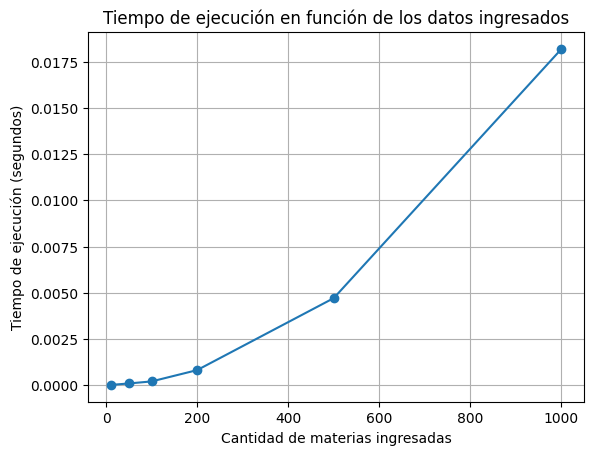

In [2]:
import time
import random
import matplotlib.pyplot as plt

def generar_materias(n):
    materias = []

    for i in range(n):
        inicio = random.randint(7, 20)
        duracion = random.randint(1, 4)
        fin = inicio + duracion

        materia = {
            "nombre": f"Materia {i + 1}",
            "prioridad": random.randint(1, 5),
            "inicio": inicio,
            "fin": fin
        }

        materias.append(materia)

    return materias


def ordenar_hora_final(materias):
    for i in range(1, len(materias)):
        actual = materias[i]
        j = i - 1

        while j >= 0 and materias[j]["fin"] > actual["fin"]:
            materias[j + 1] = materias[j]
            j -= 1

        materias[j + 1] = actual


def crear_horario(materias):
    horario = []

    for materia in materias:
        if not horario:
            horario.append(materia)
        else:
            if materia["inicio"] >= horario[-1]["fin"]:
                horario.append(materia)

    return horario


tamanos = [10, 50, 100, 200, 500, 1000]
tiempos = []

for n in tamanos:
    materias = generar_materias(n)

    inicio = time.time()

    ordenar_hora_final(materias)
    horario = crear_horario(materias)

    fin = time.time()

    tiempos.append(fin - inicio)


plt.plot(tamanos, tiempos, marker="o")
plt.xlabel("Cantidad de materias ingresadas")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.title("Tiempo de ejecución en función de los datos ingresados")
plt.grid(True)
plt.show()

### Interpretación de resultados

La gráfica muestra que el tiempo de ejecución aumenta de manera no lineal conforme crece la cantidad de materias.

Se observa un crecimiento acelerado en los valores más grandes, lo cual es característico de un comportamiento cuadrático.

Esto se debe a que el algoritmo de ordenamiento utilizado (insertion sort) tiene una complejidad en el peor caso de O(n²), la cual domina el tiempo total del programa, ya que la función de creación del horario tiene complejidad lineal O(n).

## 3.5 Pruebas

### 3.5.1 Caso de prueba 1: materias sin empalme

| Materia | Prioridad | Inicio | Fin |
|---|---:|---:|---:|
| Cálculo Integral | 3 | 7 | 9 |
| Álgebra Lineal | 5 | 9 | 11 |
| EDA | 4 | 11 | 13 |
| Mecánica | 2 | 13 | 15 |
| Redacción | 1 | 15 | 17 |

**Resultado esperado:**  
Todas las materias se agregan al horario, ya que ninguna se empalma con otra.

| Materia seleccionada | Inicio | Fin |
|---|---:|---:|
| Cálculo Integral | 7 | 9 |
| Álgebra Lineal | 9 | 11 |
| EDA | 11 | 13 |
| Mecánica | 13 | 15 |
| Redacción | 15 | 17 |

### 3.5.2 Prueba 2: materias con empalme

| Materia | Prioridad | Inicio | Fin |
|---|---:|---:|---:|
| Cálculo Integral | 3 | 7 | 10 |
| Álgebra Lineal | 5 | 9 | 11 |
| EDA | 4 | 11 | 13 |
| Mecánica | 2 | 13 | 15 |
| Redacción | 1 | 15 | 17 |

**Conflicto detectado:**  
`Cálculo Integral` se empalma con `Álgebra Lineal`.

Si el usuario elige la opción `2`, se conserva `Álgebra Lineal`.

| Materia seleccionada | Inicio | Fin |
|---|---:|---:|
| Álgebra Lineal | 9 | 11 |
| EDA | 11 | 13 |
| Mecánica | 13 | 15 |
| Redacción | 15 | 17 |